# init

## setup environments

In [1]:
!crunch --env staging setup-notebook causality-discovery 0LieCWz8NrSdOTsZFGE39SaV --no-data

environment: forcing staging urls, ignoring $API_BASE_URL and $WEB_BASE_URL
crunch-cli, version 11.0.0

---
Your token seems to have expired or is invalid.

Please follow this link to copy and paste your new setup command:
https://hub.crunchdao.io/competitions/causality-discovery/submit

If you think that is an error, please contact an administrator.


In [2]:
%env API_BASE_URL=https://api.hub.crunchdao.io/
%env WEB_BASE_URL=https://hub.crunchdao.io/

import crunch.store
crunch.store.load_from_env()

env: API_BASE_URL=https://api.hub.crunchdao.io/
env: WEB_BASE_URL=https://hub.crunchdao.io/


In [3]:
import crunch

crunch = crunch.load_notebook()

loaded inline runner with module: <module '__main__'>

cli version: 11.0.0
available ram: 31.00 gb
available cpu: 8 core
----


In [36]:
import pandas as pd
from matplotlib import pyplot as plt
import networkx as nx
import numpy as np

# load dataset

In [4]:
X_train, y_train, X_test = crunch.load_data()

data/y_test_reduced.pickle: download from https:crunchdao--competition--staging.s3-accelerate.amazonaws.com/data-releases/48/y_test_reduced.pickle (562930 bytes)
data/y_test_reduced.pickle: already exists, file length match
data/y_train.pickle: download from https:crunchdao--competition--staging.s3-accelerate.amazonaws.com/data-releases/48/y_train.pickle (7017735 bytes)
data/y_train.pickle: already exists, file length match
data/X_test_reduced.pickle: download from https:crunchdao--competition--staging.s3-accelerate.amazonaws.com/data-releases/48/X_test_reduced.pickle (122341879 bytes)
data/X_test_reduced.pickle: already exists, file length match
data/X_train.pickle: download from https:crunchdao--competition--staging.s3-accelerate.amazonaws.com/data-releases/48/X_train.pickle (1523944532 bytes)
data/X_train.pickle: already exists, file length match
data/example_prediction_reduced.parquet: download from https:crunchdao--competition--staging.s3-accelerate.amazonaws.com/data-releases/48/

## utilities

In [37]:
def graph_nodes_representation(graph, nodelist):
    adjacency_matrix = nx.adjacency_matrix(graph, nodelist=nodelist).todense()
    return tuple(adjacency_matrix.flatten())

def create_graph_label():
    graph_label = {
        nx.DiGraph([("X", "Y"), ("v", "X"), ("v", "Y")]): "Confounder",
        nx.DiGraph([("X", "Y"), ("X", "v"), ("Y", "v")]): "Collider",
        nx.DiGraph([("X", "Y"), ("X", "v"), ("v", "Y")]): "Mediator",
        nx.DiGraph([("X", "Y"), ("v", "X")]): "Cause of X",
        nx.DiGraph([("X", "Y"), ("v", "Y")]): "Cause of Y",
        nx.DiGraph([("X", "Y"), ("X", "v")]): "Consequence of X",
        nx.DiGraph([("X", "Y"), ("Y", "v")]): "Consequence of Y",
        nx.DiGraph({"X": ["Y"], "v": []}): "Independent",
    }
    nodelist = ["v", "X", "Y"]
    adjacency_label = {
        graph_nodes_representation(graph, nodelist): label
        for graph, label in graph_label.items()
    }
    return graph_label, adjacency_label

_GRAPH_LABEL, _ADJACENCY_LABEL = None, None

def get_adjacency_label():
    global _GRAPH_LABEL, _ADJACENCY_LABEL
    if _ADJACENCY_LABEL is None:
        _GRAPH_LABEL, _ADJACENCY_LABEL = create_graph_label()
    return _ADJACENCY_LABEL

def get_labels(adjacency_matrix, adjacency_label):
    result = {}
    for variable in adjacency_matrix.columns.drop(["X", "Y"]):
        submatrix = adjacency_matrix.loc[
            [variable, "X", "Y"], [variable, "X", "Y"]
        ]
        key = tuple(submatrix.values.flatten())
        result[variable] = adjacency_label[key]
    return result

def transform_proba_to_DAG(nodes, pred):
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edge("X", "Y")
    x_index, y_index = np.unravel_index(
        np.argsort(pred.ravel())[::-1], pred.shape
    )
    for i, j in zip(x_index, y_index):
        n1, n2 = nodes[i], nodes[j]
        if i == j:
            continue
        if {n1, n2} == {"X", "Y"}:
            continue
        if pred[i, j] > 0.5:
            G.add_edge(n1, n2)
            if not nx.is_directed_acyclic_graph(G):
                G.remove_edge(n1, n2)
    return nx.to_numpy_array(G)

def _edge_type(u_name, v_name):
    """Edge type encoding (7 types) as described in the report."""
    uX, uY = u_name == "X", u_name == "Y"
    vX, vY = v_name == "X", v_name == "Y"
    if uX and not vY:  return 0   # u=X, v≠Y
    if uX and vY:      return 1   # u=X, v=Y
    if uY and not vX:  return 2   # u=Y, v≠X
    if uY and vX:      return 3   # u=Y, v=X
    if not uX and not uY and vX: return 4  # u∉{X,Y}, v=X
    if not uX and not uY and vY: return 5  # u∉{X,Y}, v=Y
    return 6                                # none of the above

# eda

In [30]:
train_names: list[str] = list(X_train.keys())
sample_train_name: str = train_names[2]
sample_train_name

'00007'

In [39]:
sample_df: pd.DataFrame = X_train[sample_train_name]
sample_df

,0,1,2,3,4,5,Y,7,8,X
0,-0.789,-0.357,0.071,0.509,-0.603,-0.861,0.617,0.559,0.999,0.671
1,0.851,0.539,0.491,0.827,0.049,0.013,-0.007,-0.667,-0.127,-0.673
2,-0.777,-0.869,-0.965,-0.877,0.025,0.837,0.657,-0.069,-0.927,-0.477
3,-0.955,0.381,-0.293,0.239,-0.629,-0.511,0.065,-0.479,0.157,0.523
4,-0.881,0.337,-0.653,-0.203,-0.521,-0.493,0.193,-0.439,-0.469,0.729
...,...,...,...,...,...,...,...,...,...,...
995,-0.035,-0.873,0.637,0.493,0.887,0.375,0.687,-0.661,0.127,-0.729
996,-0.229,0.467,-0.435,-0.399,0.839,0.795,0.075,-0.927,-0.465,-0.593
997,0.149,-0.037,0.985,0.515,0.491,0.427,0.549,-0.361,0.061,-0.769
998,0.175,-0.085,0.563,0.377,-0.601,-0.417,-0.257,0.765,0.241,0.251


In [60]:
adj_df: pd.DataFrame = y_train[sample_train_name]
adj_df

,0,1,2,3,4,5,Y,7,8,X
parent,,,,,,,,,,
0,0,0,1,0,0,0,1,0,0,0
1,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,0,1,0
3,0,0,1,0,0,1,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,1,0,0,0,1,0
Y,0,0,0,0,0,0,0,1,0,0
7,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,1,0,0,0,0,0


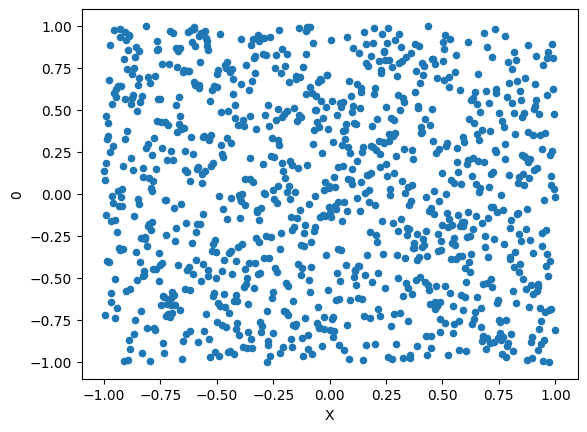

In [68]:
def plot_scatter(df: pd.DataFrame, x_col: str, y_col: str):
    sorted_df: pd.DataFrame = df[[x_col, y_col]].sort_values(x_col)

    sorted_df.plot(x = x_col, y = y_col, kind = 'scatter')

plot_scatter(sample_df, 'X', '0')

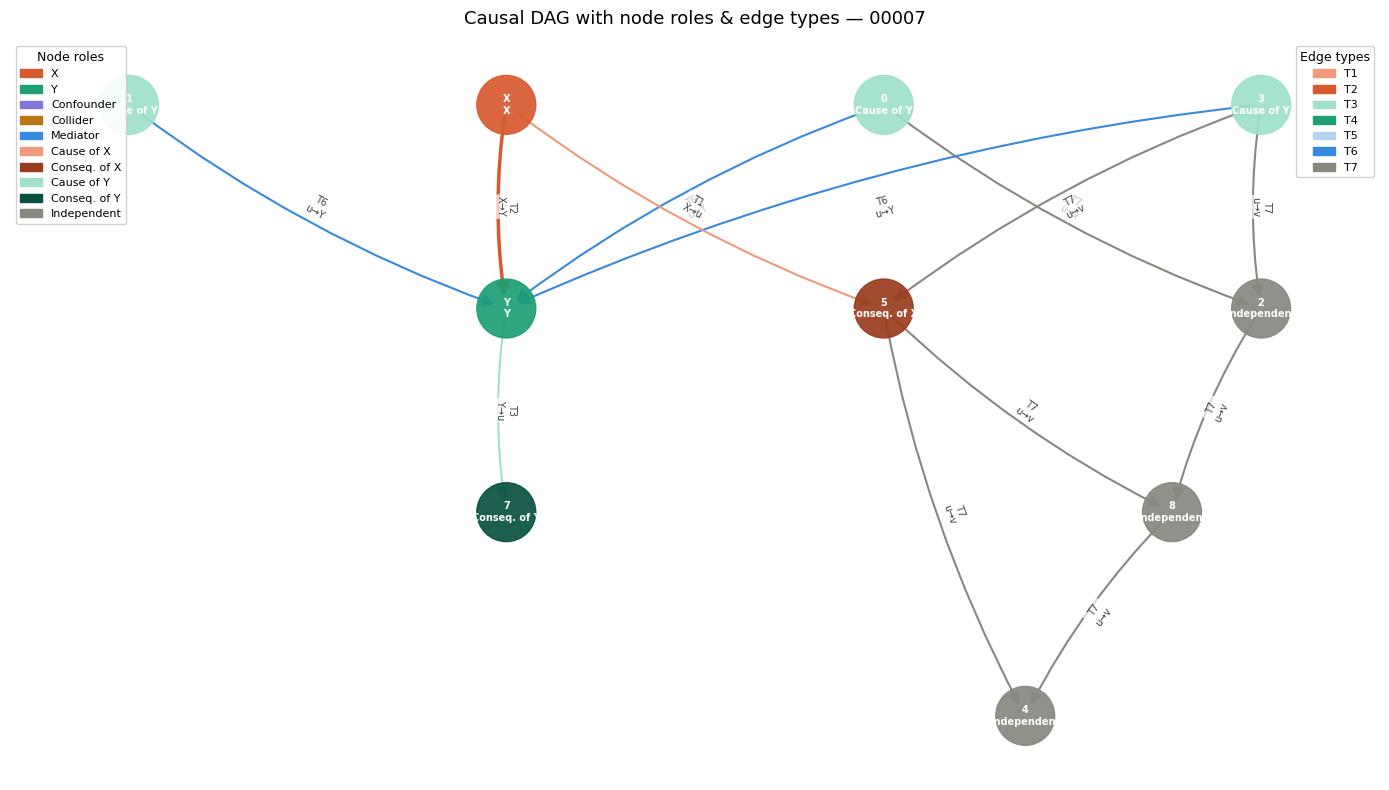

In [74]:
# ── Build graph ───────────────────────────────────────────────────────────────
from mpmath import mp
from matplotlib import patches as mpatches
G = nx.DiGraph()
for parent in adj_df.index:
    for child in adj_df.columns:
        if adj_df.loc[parent, child] == 1:
            G.add_edge(parent, child)

# ── Edge type classifier (1-7) ────────────────────────────────────────────────
def edge_type(u, v):
    if u == 'X' and v != 'Y': return 1, 'X→u'
    if u == 'X' and v == 'Y': return 2, 'X→Y'
    if u == 'Y' and v != 'X': return 3, 'Y→u'
    if u == 'Y' and v == 'X': return 4, 'Y→X'
    if u not in ('X','Y') and v == 'X': return 5, 'u→X'
    if u not in ('X','Y') and v == 'Y': return 6, 'u→Y'
    return 7, 'u→v'

# ── Node role classifier ──────────────────────────────────────────────────────
def node_role(k):
    if k in ('X', 'Y'):
        return k  # keep X and Y labelled as-is
    kx = G.has_edge(k, 'X')
    ky = G.has_edge(k, 'Y')
    xk = G.has_edge('X', k)
    yk = G.has_edge('Y', k)
    # priority order matters for nodes that could match multiple patterns
    if kx and ky:           return 'Confounder'
    if xk and yk:           return 'Collider'
    if xk and ky:           return 'Mediator'
    if yk:                  return 'Conseq. of Y'
    if xk:                  return 'Conseq. of X'
    if kx:                  return 'Cause of X'
    if ky:                  return 'Cause of Y'
    return 'Independent'

# ── Assign roles and edge labels ──────────────────────────────────────────────
roles       = {n: node_role(n) for n in G.nodes}
edge_labels = {(u, v): f"T{edge_type(u,v)[0]}\n{edge_type(u,v)[1]}" for u,v in G.edges}

# ── Color maps ────────────────────────────────────────────────────────────────
role_colors = {
    'X':             '#D85A30',   # coral  — treatment
    'Y':             '#1D9E75',   # teal   — outcome
    'Confounder':    '#7F77DD',   # purple
    'Collider':      '#BA7517',   # amber
    'Mediator':      '#378ADD',   # blue
    'Cause of X':    '#F0997B',   # light coral
    'Conseq. of X':  '#993C1D',   # dark coral
    'Cause of Y':    '#9FE1CB',   # light teal
    'Conseq. of Y':  '#085041',   # dark teal
    'Independent':   '#888780',   # gray
}

edge_type_colors = {1:'#F0997B', 2:'#D85A30', 3:'#9FE1CB', 4:'#1D9E75', 5:'#B5D4F4', 6:'#378ADD', 7:'#888780'}
edge_colors = [edge_type_colors[edge_type(u,v)[0]] for u,v in G.edges]
edge_widths = [2.5 if edge_type(u,v)[0] in (2,) else 1.5 for u,v in G.edges]  # highlight X→Y

# ── Node display labels: "id\nRole" ───────────────────────────────────────────
node_labels = {n: f"{n}\n{roles[n]}" for n in G.nodes}
node_colors = [role_colors.get(roles[n], '#888780') for n in G.nodes]

# ── Layout and draw ───────────────────────────────────────────────────────────
try:
    pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
except Exception:
    pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(14, 8))

nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1800, alpha=0.92)
nx.draw_networkx_labels(G, pos, ax=ax, labels=node_labels,
                        font_size=7, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths,
                       arrows=True, arrowsize=18,
                       connectionstyle='arc3,rad=0.08')  # slight curve avoids overlap
nx.draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=edge_labels,
                              font_size=7, font_color='#3d3d3a',
                              bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

# ── Legends ───────────────────────────────────────────────────────────────────
node_legend = [mpatches.Patch(color=c, label=r) for r, c in role_colors.items()]
edge_legend = [mpatches.Patch(color=c, label=f"T{t}") for t, c in edge_type_colors.items()]

leg1 = ax.legend(handles=node_legend, title='Node roles',
                 loc='upper left', fontsize=8, title_fontsize=9, framealpha=0.9)
ax.legend(handles=edge_legend, title='Edge types',
          loc='upper right', fontsize=8, title_fontsize=9, framealpha=0.9)
ax.add_artist(leg1)

ax.set_title(f'Causal DAG with node roles & edge types — {sample_train_name}', fontsize=13, pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

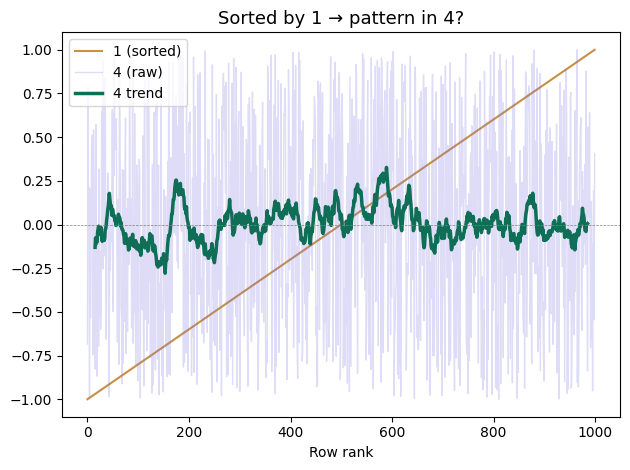

In [86]:
# --- 2. Sorted variable plot ---
sort_var, compare_var = '1', '4'
df_sorted = sample_df.sort_values(by=sort_var).reset_index(drop=True)

plt.plot(df_sorted[sort_var].values, alpha=0.8, label=f'{sort_var} (sorted)', lw=1.5, color='#BA7517')
plt.plot(df_sorted[compare_var].values, alpha=0.25, label=f'{compare_var} (raw)', lw=1, color='#7F77DD')
plt.plot(df_sorted[compare_var].rolling(30, center=True).mean().values,
             label=f'{compare_var} trend', lw=2.5, color='#0F6E56')
plt.axhline(0, color='gray', lw=0.5, ls='--')
plt.title(f'Sorted by {sort_var} → pattern in {compare_var}?', fontsize=13)
plt.legend(fontsize=10)
plt.xlabel('Row rank')
plt.tight_layout()
plt.show()